# 1. Data Preparation and Visualization

##  1.1. Problem Description

**Grape Valley Winery**, a company specialized in producing natural fruit juices—particularly grape juice—faces a challenge related to the **health of vine leaves**, a factor directly linked to the **final quality of the grapes** and, consequently, of the juice produced.

In recent harvest seasons, the winery has observed **variations in grape quality**, associated with the presence of **diseases and anomalies in vine leaves**. These issues affect photosynthesis and plant nutrition, leading to lower yields and reduced grape quality.

Currently, the identification of diseased leaves is performed **manually by field workers**, a process that is **time-consuming, subjective, and prone to human error**. To optimize this process, it is proposed to develop an **image classification model based on Convolutional Neural Networks (CNNs)** capable of **automatically distinguishing between healthy and unhealthy vine leaves** from images captured in the field.

This model aims to support the winery in **early disease detection**, **reducing agricultural losses**, and **improving production quality**, promoting a more **efficient, accurate, and sustainable** approach to vineyard monitoring.


##  1.2. Loading the Data

Configures TensorFlow for optimal GPU memory usage and mixed precision.

In [1]:
import tensorflow as tf
from tensorflow.keras import mixed_precision

def setup_tensorflow(gpu_growth=True, mixed_precision_enabled=True):
    """
    Configures TensorFlow for optimal GPU memory usage and mixed precision.
    
    Parameters:
    - gpu_growth (bool): Enables dynamic GPU memory growth.
    - mixed_precision_enabled (bool): Enables mixed precision (float16) for efficiency.
    """
    
    # Clear any existing session
    tf.keras.backend.clear_session()
    
    # Set mixed precision if enabled
    if mixed_precision_enabled:
        policy = mixed_precision.Policy('mixed_float16')
        mixed_precision.set_global_policy(policy)
        print("Mixed precision enabled: float16")

    # Enable dynamic GPU memory growth if enabled
    if gpu_growth:
        gpus = tf.config.list_physical_devices('GPU')
        if gpus:
            try:
                for gpu in gpus:
                    tf.config.experimental.set_memory_growth(gpu, True)
                print(f"Memory growth enabled for {len(gpus)} GPU(s)")
            except RuntimeError as e:
                print(f"Error setting GPU memory growth: {e}")

2025-10-21 18:36:42.113229: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-10-21 18:36:42.247073: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-10-21 18:36:44.467285: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Importing image datasets

In [2]:
url = 'grapes'

In [3]:
import pathlib

In [4]:
data_dir=pathlib.Path(url)

In [5]:
len(list(data_dir.glob('*/*.JPG')))

1600

In [6]:
# Lists all subfolders (and files, if any) in the specified directory
subfolders = [f.name for f in data_dir.iterdir() if f.is_dir()]
subfolders

['LeafBlight', 'BlackMeasles', 'HealthyGrapes', 'BlackRot']

In [7]:
import os
from PIL import Image

In [8]:
leafblight = list(data_dir.glob('LeafBlight/*'))

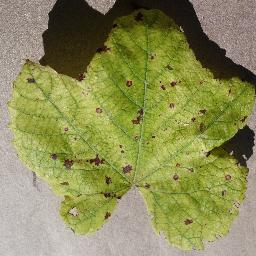

In [9]:
# Assuming leafblight is a list of paths
leafblight = [f for f in leafblight if os.path.splitext(f)[1].lower() in ['.jpg', '.jpeg', '.png']]

# Open the first valid image
img = Image.open(leafblight[0])
img.show()


## 1.3. Data Exploration and Visualization

Understanding Dimensions and Color Channels

In [10]:
# Checking the number of images per class and obtaining information from a sample image

from PIL import Image
import numpy as np
from pathlib import Path

In [11]:
# Assuming `data_dir` and `subfolders` are already defined

for subfolder in subfolders:
    path = data_dir / subfolder
    images = list(path.glob('*.JPG'))
    print(f"Class '{subfolder}' has {len(images)} images.")

    # Checking the dimensions and channels of a sample image
    if images:
        img = Image.open(str(images[0]))  # Note: we use Image, not PIL.Image
        img_array = np.array(img)
        print(f"Dimensions of the first image in '{subfolder}': {img_array.shape}")

Class 'LeafBlight' has 400 images.
Dimensions of the first image in 'LeafBlight': (256, 256, 3)
Class 'BlackMeasles' has 400 images.
Dimensions of the first image in 'BlackMeasles': (256, 256, 3)
Class 'HealthyGrapes' has 400 images.
Dimensions of the first image in 'HealthyGrapes': (256, 256, 3)
Class 'BlackRot' has 400 images.
Dimensions of the first image in 'BlackRot': (256, 256, 3)


* RGB (255,0,0) represents pure red.
* RGB (0,255,0) represents pure green.
* RGB (0,0,255) represents pure **blue**.
* RGB (0,0,0) is black because no light is being emitted.
* RGB (255,255,255) is white because all channels are emitting light at maximum, combining red, green, and blue light to create white.


## 1.4. Loading data with TensorFlow


In [12]:
import tensorflow as tf

In [13]:
# Check TensorFlow version and GPU availability
print("TensorFlow Version:", tf.__version__)
print("Available GPUs:", tf.config.list_physical_devices('GPU'))

if tf.config.list_physical_devices('GPU'):
    print("✅ GPU detected and active!")
else:
    print("❌ GPU not detected.")

TensorFlow Version: 2.20.0
Available GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
✅ GPU detected and active!


In [14]:
batch_size = 32
height = 256
width = 256

In [15]:
train = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset='training',
    seed=568,
    image_size=(height,width),
    batch_size=batch_size
)

Found 1600 files belonging to 4 classes.
Using 1280 files for training.


I0000 00:00:1761082607.791627   27696 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1766 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


In [16]:
validation = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset='validation',
    seed=568,
    image_size=(height,width),
    batch_size=batch_size
)

Found 1600 files belonging to 4 classes.
Using 320 files for validation.


In [17]:
train.class_names

['BlackMeasles', 'BlackRot', 'HealthyGrapes', 'LeafBlight']

# 2. Training and Improving the Network

## 2.1. Building a Multi-Layer Perceptron

In [18]:
tf.random.set_seed(42)

In [19]:
setup_tensorflow()

Mixed precision enabled: float16
Error setting GPU memory growth: Physical devices cannot be modified after being initialized


In [20]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(256, 256, 3)),
    tf.keras.layers.Rescaling(1./255),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation=tf.nn.relu),
    tf.keras.layers.Dense(4, activation=tf.nn.softmax)
])

* [Sequential](https://www.tensorflow.org/api_docs/python/tf/keras/Sequential): Defines a sequence of layers in the neural network.
* [Rescaling](https://www.tensorflow.org/api_docs/python/tf/keras/layers/Rescaling): A preprocessing layer that rescales input values to a new range.
* [Flatten](https://www.tensorflow.org/api_docs/python/tf/keras/layers/Flatten): The Flatten method takes the three-dimensional image matrix, which was originally 256x256x3, and converts it into a one-dimensional array with 196,608 values in this case. This is because the multiplication 256×256×3 equals 196,608.
* [Dense](https://www.tensorflow.org/api_docs/python/tf/keras/layers/Dense): Adds a layer of neurons.
* [ReLU](https://www.tensorflow.org/api_docs/python/tf/nn/relu): An activation function that processes each neuron's output as follows:

  If x > 0: returns x;
  Otherwise: returns 0;

  In other words, it only passes values greater than zero to the next layer.

* [Softmax](https://www.tensorflow.org/api_docs/python/tf/nn/softmax): An activation function that takes a list of values and scales them so that the sum of all elements equals 1. When applied to the model's output, you can think of the scaled values as the probability for each class. For example, in a classification model with 4 units in the output dense layer, having the highest value at index = 3 means the model is most confident that the input image belongs to the LeafBlight class.


In [21]:
model.compile(optimizer = tf.keras.optimizers.Adam(),
              loss = 'sparse_categorical_crossentropy',
              metrics=['accuracy'])

## 2.2. Training the Model

In [22]:
epochs = 10

history = model.fit(
    train,
    validation_data=validation,
    epochs=epochs,
    batch_size=batch_size
)

Epoch 1/10


2025-10-21 18:36:50.508980: I external/local_xla/xla/service/service.cc:163] XLA service 0x7c0c2c016c60 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-10-21 18:36:50.509023: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 3050 Laptop GPU, Compute Capability 8.6
2025-10-21 18:36:50.531137: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-10-21 18:36:50.656500: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91400


12/40 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.2463 - loss: 9.5344

I0000 00:00:1761082611.828616   29003 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


36/40 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.2413 - loss: 11.0562

2025-10-21 18:36:53.277625: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_38', 252 bytes spill stores, 252 bytes spill loads



40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step - accuracy: 0.2484 - loss: 11.8611 - val_accuracy: 0.2469 - val_loss: 12.1389
Epoch 2/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.2508 - loss: 12.0760 - val_accuracy: 0.2469 - val_loss: 12.1389
Epoch 3/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.2508 - loss: 12.0760 - val_accuracy: 0.2469 - val_loss: 12.1389
Epoch 4/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 7s 181ms/step - accuracy: 0.2508 - loss: 12.0760 - val_accuracy: 0.2469 - val_loss: 12.1389
Epoch 5/10
40/40 ━━━━━━━━━━━━━━━━━━━━ -6s -158318us/step - accuracy: 0.2508 - loss: 12.0760 - val_accuracy: 0.2469 - val_loss: 12.1389
Epoch 6/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.2508 - loss: 12.0760 - val_accuracy: 0.2469 - val_loss: 12.1389
Epoch 7/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.2508 - loss: 12.0760 - val_accuracy: 0.2469 - val_loss: 12.1389
Epoch 8/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.2508 - loss: 12.0760 - val_accuracy:

In [23]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 196608)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    25,165,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 75,499,410 (288.01 MB)

 Trainable params: 25,166,468 (96.00 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 50,332,942 (192.00 MB)

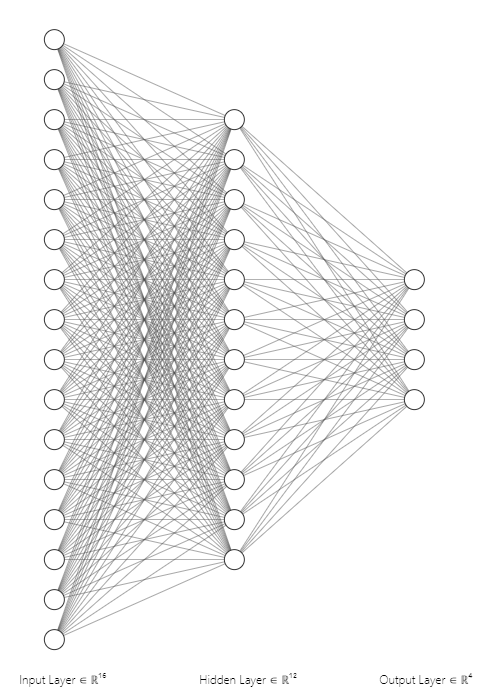

## 2.3. Checking the Results

In [24]:
import matplotlib.pyplot as plt

In [25]:
def plot_results(history,epochs):
  acc = history.history['accuracy']
  val_acc = history.history['val_accuracy']

  loss = history.history['loss']
  val_loss = history.history['val_loss']

  epochs_interval = range(epochs)
  plt.figure(figsize=(12, 6))
  plt.subplot(1, 2, 1)
  plt.plot(epochs_interval, acc, label='Training Accuracy')
  plt.plot(epochs_interval, val_acc, label='Validation Accuracy')
  plt.legend(loc='lower right')


  plt.subplot(1, 2, 2)
  plt.plot(epochs_interval, loss, label='Training Loss')
  plt.plot(epochs_interval, val_loss, label='Validation Loss')
  plt.legend(loc='upper right')
  plt.show()


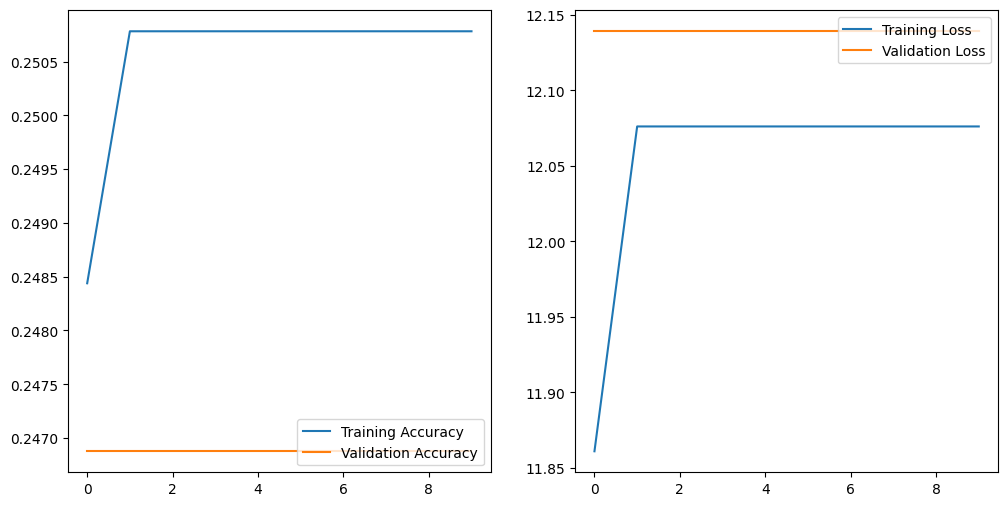

In [26]:
plot_results(history,epochs)

# 3. Adding Convolutional Layers

## 3.1. Structuring a Convolutional Neural Network


In [27]:
setup_tensorflow()

Mixed precision enabled: float16
Error setting GPU memory growth: Physical devices cannot be modified after being initialized


In [28]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(256, 256, 3)),
    tf.keras.layers.Rescaling(1./255),
    # Add convolutions and max pooling
    tf.keras.layers.Conv2D(16, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Conv2D(16, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128,activation=tf.nn.relu),
    tf.keras.layers.Dense(4, activation=tf.nn.softmax)
])

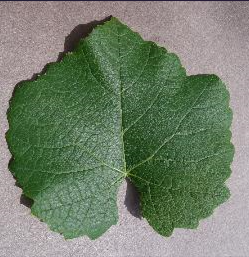

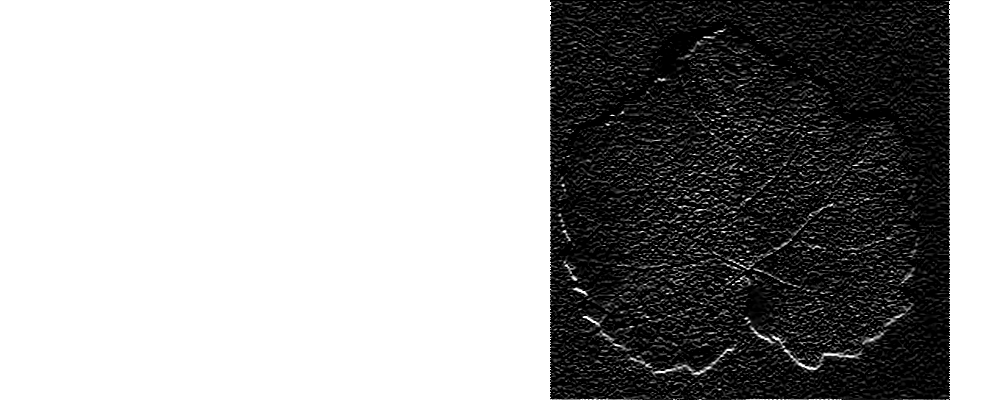

In [29]:
model.compile(optimizer = tf.keras.optimizers.Adam(),
              loss = 'sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [30]:
epochs = 10

history = model.fit(
    train,
    validation_data=validation,
    epochs=epochs,
    batch_size=batch_size
)

Epoch 1/10


2025-10-21 18:37:01.400722: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.


39/40 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.2676 - loss: 8.5271

2025-10-21 18:37:22.451258: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng23{k2=8,k12=-1,k13=1,k14=4,k15=0,k17=3,k18=0,k23=0} for conv (f16[32,254,254,16]{3,2,1,0}, u8[0]{0}) custom-call(f16[32,256,256,3]{3,2,1,0}, f16[16,3,3,3]{3,2,1,0}, f16[16]{0}), window={size=3x3}, dim_labels=b01f_o01i->b01f, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kRelu","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]} is taking a while...
2025-10-21 18:37:22.548346: E external/local_xla/xla/service/slow_operation_alarm.cc:140] The operation took 6.467983836s
Trying algorithm eng23{k2=8,k12=-1,k13=1,k14=4,k15=0,k17=3,k18=0,k23=0} for conv (f16[32,254,254,16]{3,2,1,0}, u8[0]{0}) custom-call(f16[32,256,256,3]{3,2,1,0}, f16[16,3,3,3]{3,2,1,0}, f16[16]{0}), window={size=3x3}, dim_l

40/40 ━━━━━━━━━━━━━━━━━━━━ 16s 63ms/step - accuracy: 0.2766 - loss: 7.0061 - val_accuracy: 0.5562 - val_loss: 1.1520
Epoch 2/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.7719 - loss: 0.6477 - val_accuracy: 0.8469 - val_loss: 0.3795
Epoch 3/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.8945 - loss: 0.2993 - val_accuracy: 0.8906 - val_loss: 0.2845
Epoch 4/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.9406 - loss: 0.1742 - val_accuracy: 0.8719 - val_loss: 0.3307
Epoch 5/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.9664 - loss: 0.1100 - val_accuracy: 0.9094 - val_loss: 0.2141
Epoch 6/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.9867 - loss: 0.0576 - val_accuracy: 0.9000 - val_loss: 0.2475
Epoch 7/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.9922 - loss: 0.0422 - val_accuracy: 0.8969 - val_loss: 0.2333
Epoch 8/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.9922 - loss: 0.0450 - val_accuracy: 0.9375 - val_loss: 0

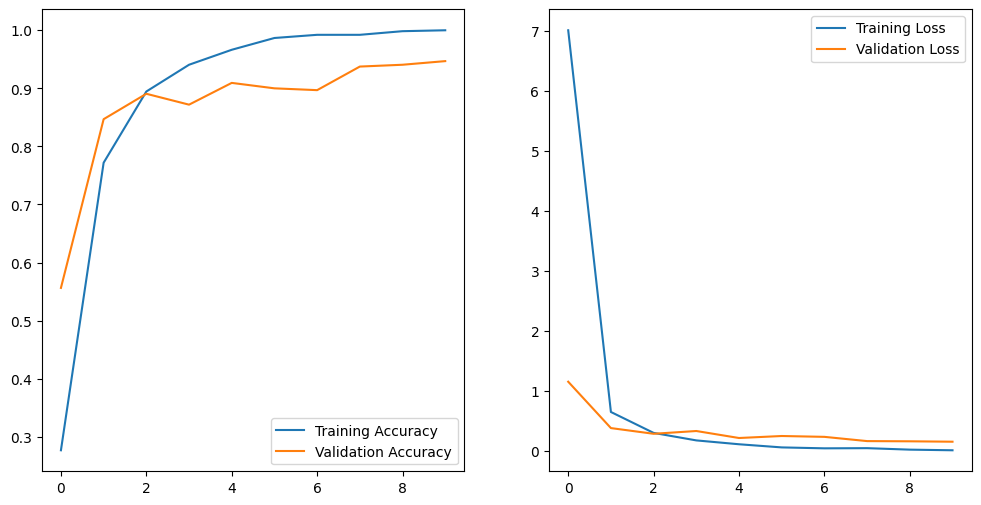

In [31]:
plot_results(history,epochs)

In [32]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 254, 254, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 16)   │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 61504)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     7,872,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,627,778 (90.13 MB)

 Trainable params: 7,875,924 (30.04 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 15,751,854 (60.09 MB)

## 3.2. Early Stopping Training

In [33]:
class myCallback(tf.keras.callbacks.Callback):
  def on_epoch_end(self, epoch, logs={}):
    if(logs.get('accuracy') >= 0.93):
      print("\n Alcançamos 93% de acurácia. Parando o treinamento!")
      self.model.stop_training = True

callbacks = myCallback()

In [34]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(256, 256, 3)),
    tf.keras.layers.Rescaling(1./255),
    # Add convolutions and max pooling
    tf.keras.layers.Conv2D(16, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Conv2D(16, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128,activation=tf.nn.relu),
    tf.keras.layers.Dense(4, activation=tf.nn.softmax)
])

model.compile(optimizer = tf.keras.optimizers.Adam(),
              loss = 'sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [35]:
epochs =10

history = model.fit(
    train,
    validation_data=validation,
    epochs=epochs,
    batch_size=batch_size,
    callbacks=[callbacks]
)

Epoch 1/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - accuracy: 0.3617 - loss: 4.1872 - val_accuracy: 0.6781 - val_loss: 0.7996
Epoch 2/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.7633 - loss: 0.6138 - val_accuracy: 0.8531 - val_loss: 0.4397
Epoch 3/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.9141 - loss: 0.2396 - val_accuracy: 0.8719 - val_loss: 0.3412
Epoch 4/10
39/40 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.9473 - loss: 0.1606
 Alcançamos 93% de acurácia. Parando o treinamento!
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.9555 - loss: 0.1516 - val_accuracy: 0.8969 - val_loss: 0.2857


## 3.3. Increasing Dataset Diversity

100 Epochs without Data Augmentation

In [36]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(256, 256, 3)),
    # data_augmentation,
    tf.keras.layers.Rescaling(1./255),
    # Add convolutions and max pooling
    tf.keras.layers.Conv2D(16, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Conv2D(16, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128,activation=tf.nn.relu),
    tf.keras.layers.Dense(4, activation=tf.nn.softmax)
])

model.compile(optimizer = tf.keras.optimizers.Adam(),
              loss = 'sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [37]:
epochs = 50

history = model.fit(
    train,
    validation_data=validation,
    epochs=epochs,
    batch_size=batch_size
)


Epoch 1/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 55ms/step - accuracy: 0.3594 - loss: 4.2806 - val_accuracy: 0.7469 - val_loss: 0.7387
Epoch 2/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.8531 - loss: 0.4234 - val_accuracy: 0.9094 - val_loss: 0.2657
Epoch 3/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.9344 - loss: 0.1977 - val_accuracy: 0.9062 - val_loss: 0.2362
Epoch 4/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.9719 - loss: 0.0977 - val_accuracy: 0.9406 - val_loss: 0.1750
Epoch 5/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.9828 - loss: 0.0579 - val_accuracy: 0.8750 - val_loss: 0.3597
Epoch 6/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.9867 - loss: 0.0492 - val_accuracy: 0.9500 - val_loss: 0.1469
Epoch 7/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.9984 - loss: 0.0159 - val_accuracy: 0.9469 - val_loss: 0.1304
Epoch 8/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 1.0000 - loss: 0.0083 - val_accuracy: 0.9500 - v

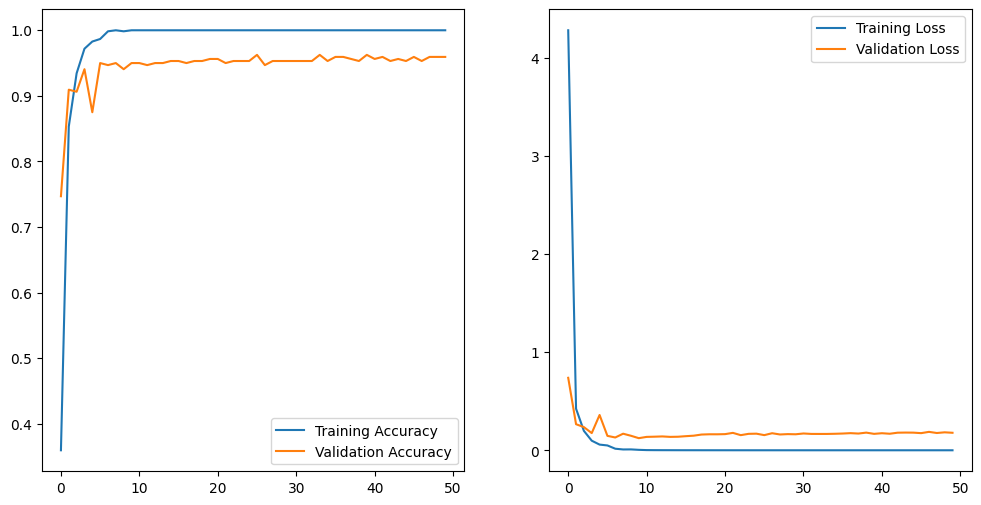

In [38]:
plot_results(history,epochs)

50 Epochs with Data Augmentation

| Layer                      | Function               | Benefit                       |
| -------------------------- | ---------------------- | ----------------------------- |
| `RandomFlip("horizontal")` | Random left-right flip | Learns orientation invariance |
| `RandomRotation(0.05)`     | Small random rotation  | Handles angle variations      |
| `RandomZoom(0.05)`         | Random zoom in/out     | Handles scale variations      |
| **Overall effect:**        | More varied dataset    | Less overfitting              |


In [39]:
data_augmentation = tf.keras.Sequential(
  [
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomZoom(0.05),
  ]
)

In [40]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(256, 256, 3)),
    data_augmentation,
    tf.keras.layers.Rescaling(1./255),
    # Add convolutions and max pooling
    tf.keras.layers.Conv2D(16, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Conv2D(16, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128,activation=tf.nn.relu),
    tf.keras.layers.Dense(4, activation=tf.nn.softmax)
])

model.compile(optimizer = tf.keras.optimizers.Adam(),
              loss = 'sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [42]:
epochs = 50

history = model.fit(
    train,
    validation_data=validation,
    epochs=epochs,
    batch_size=batch_size
)

Epoch 1/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - accuracy: 0.5461 - loss: 1.2768 - val_accuracy: 0.5437 - val_loss: 2.2434
Epoch 2/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - accuracy: 0.8516 - loss: 0.3887 - val_accuracy: 0.6781 - val_loss: 1.7177
Epoch 3/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 0.8297 - loss: 0.4172 - val_accuracy: 0.7469 - val_loss: 1.1153
Epoch 4/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - accuracy: 0.8938 - loss: 0.2812 - val_accuracy: 0.7063 - val_loss: 1.7459
Epoch 5/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - accuracy: 0.9000 - loss: 0.2496 - val_accuracy: 0.7594 - val_loss: 1.1490
Epoch 6/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - accuracy: 0.9305 - loss: 0.1856 - val_accuracy: 0.8094 - val_loss: 1.0138
Epoch 7/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - accuracy: 0.9180 - loss: 0.2144 - val_accuracy: 0.7406 - val_loss: 1.6769
Epoch 8/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - accuracy: 0.9453 - loss: 0.1637 - val_accuracy: 0.7844 - v

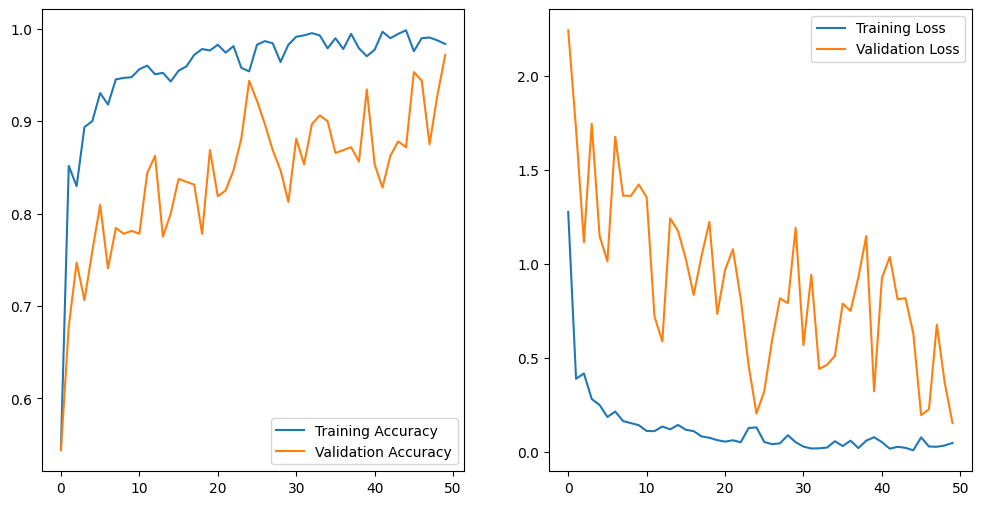

In [43]:
plot_results(history,epochs)

In [44]:
# Save the Model
from keras.saving import save_model
save_model(model, 'model_after_augmentation.keras')

# 4. Applying Pretrained Models

## 4.1. Using Pretrained Models

| Argument                      | Description                                                                                                                                                                                                   |
| ----------------------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **`input_shape=input_shape`** | Defines the expected input size of your images, for example `(256, 256, 3)`. This tells the model what shape each input image will have.                                                                      |
| **`include_top=False`**       | Removes the **fully connected layers** (the classification head) from the top of InceptionV3. That means you’ll only get the **convolutional base** — useful for **feature extraction or transfer learning**. |
| **`weights='imagenet'`**      | Loads **pretrained weights** from the **ImageNet** dataset (over 1 million labeled images, 1000 categories). This gives your model a very strong starting point, instead of training from scratch.            |


In [45]:
input_shape=(256, 256, 3)

In [46]:
model_base = tf.keras.applications.InceptionV3(input_shape=input_shape,include_top=False,weights='imagenet' )

The [InceptionV3](https://www.tensorflow.org/api_docs/python/tf/keras/applications/InceptionV3) model includes multiple filters of different sizes in each layer, allowing it to capture patterns at various scales. This can be useful to ensure that all relevant features of the leaves are considered. In the command, we are using the weights obtained from training the Inception model on the [ImageNet](https://www.image-net.org/) dataset. By setting the parameter `include_top=False`, we exclude the classification layers. This is because most machine learning model diagrams are structured from bottom to top.


In [47]:
model_base.trainable = False

In [48]:
model_base.summary()

Model: "inception_v3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 127, 127,  │        864 │ input_layer_5[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 127, 127,  │         96 │ conv2d_8[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 127, 127,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 125, 125,  │      9,216 │ activation[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 125, 125,  │         96 │ conv2d_9[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 125, 125,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_10 (Conv2D)  │ (None, 125, 125,  │     18,432 │ activation_1[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 125, 125,  │        192 │ conv2d_10[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 125, 125,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_8     │ (None, 62, 62,    │          0 │ activation_2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_11 (Conv2D)  │ (None, 62, 62,    │      5,120 │ max_pooling2d_8[… │
│                     │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 62, 62,    │        240 │ conv2d_11[0][0]   │
│ (BatchNormalizatio… │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 62, 62,    │          0 │ batch_normalizat… │
│ (Activation)        │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_12 (Conv2D)  │ (None, 60, 60,    │    138,240 │ activation_3[0][… │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 60, 60,    │        576 │ conv2d_12[0][0]   │
│ (BatchNormalizatio… │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 60, 60,    │          0 │ batch_normalizat

 Total params: 21,802,784 (83.17 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 21,802,784 (83.17 MB)

## 4.2. Transfer Learning

In [49]:
rescale = tf.keras.layers.Rescaling((1./255))
train = train.map(lambda x, y: (rescale(x), y))
validation = validation.map(lambda x, y: (rescale(x), y))

In [50]:
Output_Layer = model_base.get_layer('mixed7')
print('Size of the Output Layer:', Output_Layer.output.shape)
final_output = Output_Layer.output

Size of the Output Layer: (None, 14, 14, 768)


In [51]:
#Global Average Pooling
x = tf.keras.layers.GlobalAveragePooling2D()(final_output)
#Batch Normalization
x = tf.keras.layers.BatchNormalization()(x)
#First Dense Layer
x = tf.keras.layers.Dense(64, activation='relu')(x)
#Dropout
x = tf.keras.layers.Dropout(0.4)(x)
#Output Layer
x = tf.keras.layers.Dense(4, activation=tf.nn.softmax)(x)
#Creating the final model
model = tf.keras. Model(inputs=model_base.input,outputs=x)

In [52]:
model.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 127, 127,  │        864 │ input_layer_5[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 127, 127,  │         96 │ conv2d_8[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 127, 127,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 125, 125,  │      9,216 │ activation[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 125, 125,  │         96 │ conv2d_9[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 125, 125,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_10 (Conv2D)  │ (None, 125, 125,  │     18,432 │ activation_1[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 125, 125,  │        192 │ conv2d_10[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 125, 125,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_8     │ (None, 62, 62,    │          0 │ activation_2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_11 (Conv2D)  │ (None, 62, 62,    │      5,120 │ max_pooling2d_8[… │
│                     │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 62, 62,    │        240 │ conv2d_11[0][0]   │
│ (BatchNormalizatio… │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 62, 62,    │          0 │ batch_normalizat… │
│ (Activation)        │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_12 (Conv2D)  │ (None, 60, 60,    │    138,240 │ activation_3[0][… │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 60, 60,    │        576 │ conv2d_12[0][0]   │
│ (BatchNormalizatio… │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 60, 60,    │          0 │ batch_normalizat

 Total params: 9,027,812 (34.44 MB)

 Trainable params: 51,012 (199.27 KB)

 Non-trainable params: 8,976,800 (34.24 MB)

In [53]:
model.compile(optimizer = tf.keras.optimizers.Adam(),
              loss = 'sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [54]:
epochs = 20

history = model.fit(
    train,
    validation_data=validation,
    epochs=epochs,
    batch_size=batch_size
)

Epoch 1/20


2025-10-21 18:41:15.700285: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-10-21 18:41:27.821087: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng51{k2=16,k13=0,k14=1,k18=0,k23=0} for conv (f16[32,14,14,128]{3,2,1,0}, u8[0]{0}) custom-call(f16[32,14,14,128]{3,2,1,0}, f16[128,7,1,128]{3,2,1,0}), window={size=7x1 pad=3_3x0_0}, dim_labels=b01f_o01i->b01f, custom_call_target="__cudnn$convForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]} is taking a while...
2025-10-21 18:41:27.822631: E external/local_xla/xla/s

40/40 ━━━━━━━━━━━━━━━━━━━━ 25s 188ms/step - accuracy: 0.8375 - loss: 0.4427 - val_accuracy: 0.7656 - val_loss: 1.1115
Epoch 2/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - accuracy: 0.9727 - loss: 0.0943 - val_accuracy: 0.9125 - val_loss: 0.9483
Epoch 3/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s -126536us/step - accuracy: 0.9766 - loss: 0.0675 - val_accuracy: 0.9750 - val_loss: 0.7790
Epoch 4/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - accuracy: 0.9852 - loss: 0.0505 - val_accuracy: 0.9875 - val_loss: 0.6310
Epoch 5/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.9852 - loss: 0.0420 - val_accuracy: 0.9906 - val_loss: 0.4845
Epoch 6/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - accuracy: 0.9953 - loss: 0.0266 - val_accuracy: 0.9906 - val_loss: 0.3570
Epoch 7/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - accuracy: 0.9953 - loss: 0.0239 - val_accuracy: 0.9906 - val_loss: 0.2473
Epoch 8/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - accuracy: 0.9945 - loss: 0.0179 - val_accuracy: 0.9812 - val_l

## 4.3. Saving the Model

Saving Options – full model, weights only, or architecture only

In [55]:
# Check if the model is not too large
print("📊 Analyzing model...")
print(f"Number of layers: {len(model.layers)}")
print(f"Number of parameters: {model.count_params():,}")

# If it has more than 50M parameters, it might take a while
if model.count_params() > 50000000:
    print("Model is very large - consider simplifying")
elif model.count_params() > 100000000:
    print("Model is extremely large - conversion may take very long")
else:
    print("Model size seems reasonable for conversion")

📊 Analyzing model...
Number of layers: 234
Number of parameters: 9,027,812
Model size seems reasonable for conversion


In [56]:
import tensorflow as tf
from tensorflow import keras

#Save full model (including optimizer and weights)
model.save('transfer_learning_model.keras')

# Save model for inference (without optimizer)
model.save('final_transfer_learning_model.keras', include_optimizer=False)

# Save only the weights
model.save_weights('model_weights.weights.h5') 

print("Models saved successfully!")

Models saved successfully!


Compress the model

In [57]:
import tensorflow as tf

# Convert the Keras model to TensorFlow Lite
tflite_converter = tf.lite.TFLiteConverter.from_keras_model(model)

In [58]:
# Fast float16 conversion (minimal optimization)
tflite_converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_converter.target_spec.supported_types = [tf.float16]

In [ ]:
# Convert the model
tflite_model = tflite_converter.convert()

INFO:tensorflow:Assets written to: /tmp/tmpqndhaqxf/assets


INFO:tensorflow:Assets written to: /tmp/tmpqndhaqxf/assets


Saved artifact at '/tmp/tmpqndhaqxf'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name='keras_tensor_45')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float16, name=None)
Captures:
  136388985469840: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136388985469072: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136388985468304: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136388985466768: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136388985469264: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136388985468112: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136388985466576: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136388985467344: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136388985469648: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136388985470416: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13638898546

In [ ]:
# Save the TFLite model
tflite_file_path = 'model_fp16_fast.tflite'
with open(tflite_file_path, 'wb') as f:
    f.write(tflite_model)

print(f"✅ Fast float16 TFLite model saved! Size: {len(tflite_model) / (1024*1024):.2f} MB")